36120


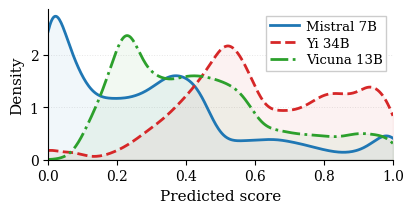

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Load score distributions
# ---------------------------
with open("datasets/routerbench_0shot_scores.pkl", "rb") as f:
    score_obj = pickle.load(f)

score_cols = score_obj["score_columns"]
scores = np.asarray(score_obj["scores"], dtype=float)
col_to_idx = {name: i for i, name in enumerate(score_cols)}

mistral_scores = scores[:, col_to_idx["mistralai/mistral-7b-chat"]]
yi_scores = scores[:, col_to_idx["zero-one-ai/Yi-34B-Chat"]]
vicuna_scores = scores[:, col_to_idx["WizardLM/WizardLM-13B-V1.2"]]
print(len(mistral_scores))
# Clip to [0, 1]
mistral_scores = np.clip(mistral_scores, 0.0, 1.0)
yi_scores = np.clip(yi_scores, 0.0, 1.0)
vicuna_scores = np.clip(vicuna_scores, 0.0, 1.0)

# ---------------------------
# Plot style for IEEE single-column figure
# ---------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "lines.linewidth": 2.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# KDE helper
# ---------------------------
def kde_pdf(samples: np.ndarray, x_grid: np.ndarray, bw: float | None = None) -> np.ndarray:
    samples = np.asarray(samples, dtype=float)
    n = samples.size
    if n == 0:
        raise ValueError("Empty samples passed to kde_pdf")

    if bw is None:
        std = samples.std(ddof=1)
        bw = 1.06 * std * (n ** (-1 / 5))
        if not np.isfinite(bw) or bw <= 0:
            bw = 1.0

    z = (x_grid[:, None] - samples[None, :]) / bw
    return (np.exp(-0.5 * z * z).mean(axis=1)) / (bw * np.sqrt(2 * np.pi))

# ---------------------------
# Evaluate KDEs
# ---------------------------
x = np.linspace(0.0, 1.0, 400)

pdf_m = kde_pdf(mistral_scores, x)
pdf_y = kde_pdf(yi_scores, x)
pdf_v = kde_pdf(vicuna_scores, x)

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(4, 2))

colors = {
    "Mistral 7B": "#1f77b4",
    "Yi 34B": "#d62728",
    "Vicuna 13B": "#2ca02c",
}
linestyles = {
    "Mistral 7B": "-",
    "Yi 34B": "--",
    "Vicuna 13B": "-.",
}

ax.plot(x, pdf_m, color=colors["Mistral 7B"], linestyle=linestyles["Mistral 7B"], label="Mistral 7B")
ax.plot(x, pdf_y, color=colors["Yi 34B"], linestyle=linestyles["Yi 34B"], label="Yi 34B")
ax.plot(x, pdf_v, color=colors["Vicuna 13B"], linestyle=linestyles["Vicuna 13B"], label="Vicuna 13B")

# Very light fills: helpful in color, still acceptable in grayscale
ax.fill_between(x, pdf_m, color=colors["Mistral 7B"], alpha=0.06)
ax.fill_between(x, pdf_y, color=colors["Yi 34B"], alpha=0.06)
ax.fill_between(x, pdf_v, color=colors["Vicuna 13B"], alpha=0.06)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(bottom=0)
ax.set_xlabel("Predicted score")
ax.set_ylabel("Density")

ax.set_xticks(np.linspace(0, 1, 6))
ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    facecolor="white",
    framealpha=1.0,
    loc="upper right",
    borderpad=0.3,
    handlelength=2.2,
    handletextpad=0.5,
    labelspacing=0.3,
)

plt.tight_layout(pad=0.2)
plt.savefig("plots/scores.pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()